# NeqSim and TornadoVM: when does GPU thermodynamics pay off?

**An executed experiment and an implementation guide for large process models.**

This notebook compares the same double-precision SRK property kernel on one CPU thread,
eight CPU workers and a CUDA GPU. It validates the extracted equations against a pinned
NeqSim `master` build, measures transfer-inclusive speed, and runs a native multi-train
`ProcessSystem` to explain why large flowsheets do not automatically make large GPU batches.

**Learning outcomes:** identify the batch-size crossover; separate kernel speed from process
speed; understand a practical route to optional GPU-assisted flash calculations.

**Scope:** classical SRK, temperature-independent binary interactions and qualified gas roots.
The GPU kernel is an experimental numerical extraction. Existing NeqSim flashes and process
units still execute on CPU. No GPU flash or production backend is implemented here.

Select **Runtime → Change runtime type → GPU**, preferably A100 for FP64, then **Run all**.
A clean setup builds NeqSim and downloads TornadoVM. Allow several minutes for setup and
about three minutes for three benchmark JVMs. No API keys or private data are required.
The notebook stops explicitly if a GPU is unavailable; it never reports CPU fallback as GPU work.


## 1. Reproducible setup

TornadoVM 6.1.0 is paired with Java 21 and CUDA. NeqSim Java source is pinned to
`e946713a2e5393cc5932ac9fcf74d6ab561221df`, the inspected `master` head on 20 September 2026.
The Python distribution supplies the bridge only; its bundled Java JAR is not used.

The official upstream SDK and NeqSim source are downloaded. Package versions, commit,
JAR hash, actual class location and hardware are retained below. Installation/build logs
are saved in `tornado_demo_outputs`; failures include the relevant log tail.


In [1]:
import importlib.metadata as metadata
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys

ARTIFACTS = Path("tornado_demo_outputs").resolve()
ARTIFACTS.mkdir(exist_ok=True)
requirements = {
    "neqsim": "3.20.0",
    "JPype1": "1.7.1",
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "matplotlib": "3.11.2",
}


def run_checked(arguments, label, cwd=None, timeout=900):
    result = subprocess.run(
        arguments,
        cwd=cwd,
        capture_output=True,
        text=True,
        timeout=timeout,
    )
    log_text = result.stdout + result.stderr
    (ARTIFACTS / f"{label}.log").write_text(log_text)
    if result.returncode != 0:
        raise RuntimeError(f"{label} failed:\n{log_text[-6000:]}")
    return result.stdout.strip()


missing = []
for package, version in requirements.items():
    try:
        installed = metadata.version(package)
    except metadata.PackageNotFoundError:
        installed = None
    if installed != version:
        missing.append(f"{package}=={version}")
if missing:
    run_checked(
        [sys.executable, "-m", "pip", "install", "-q", *missing],
        "python_install",
    )
assert shutil.which("java"), "Install Java 21 before continuing."
java_home = Path(shutil.which("java")).resolve().parent.parent
os.environ["JAVA_HOME"] = str(java_home)
java_version = subprocess.run(["java", "-version"], capture_output=True, text=True)
assert 'version "21.' in java_version.stderr, "Select a Java 21 runtime for this SDK."
assert shutil.which("nvidia-smi"), "Select a CUDA GPU runtime in Colab, then run again."
hardware = run_checked(["nvidia-smi"], "gpu_hardware")
print(java_version.stderr.strip())
print(hardware)


openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
Sun Sep 20 20:35:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             44W /  400W |       0MiB 

In [2]:
import hashlib
import json
import urllib.parse
import urllib.request
import zipfile

NEQSIM_SOURCE_REF = "e946713a2e5393cc5932ac9fcf74d6ab561221df"
source_root = Path("neqsim-source").resolve()
if not (source_root / ".git").exists():
    run_checked(["git", "init", str(source_root)], "git_init")
    run_checked(
        ["git", "remote", "add", "origin", "https://github.com/equinor/neqsim.git"],
        "git_remote",
        source_root,
    )
run_checked(
    ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
    "git_fetch",
    source_root,
)
run_checked(["git", "checkout", "--detach", "FETCH_HEAD"], "git_checkout", source_root)
resolved_commit = run_checked(["git", "rev-parse", "HEAD"], "git_commit", source_root)
assert resolved_commit == NEQSIM_SOURCE_REF
assert not run_checked(["git", "diff", "HEAD", "--", "src", "pom.xml"], "git_diff", source_root)
run_checked(
    [
        "bash", "mvnw", "-q", "-Dmaven.test.skip=true", "-Dmaven.javadoc.skip=true",
        "-Dcheckstyle.skip", "-Dspotbugs.skip", "-Dpmd.skip=true", "-Djacoco.skip=true",
        "package",
    ],
    "neqsim_build",
    source_root,
    timeout=1200,
)
runtime_jars = [
    path for path in (source_root / "target").glob("neqsim-*.jar")
    if not any(word in path.name for word in ("sources", "javadoc", "tests"))
]
assert len(runtime_jars) == 1
source_jar = runtime_jars[0].resolve()
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

import jpype

assert not jpype.isJVMStarted(), "Restart the session before loading the pinned source JAR."
jpype.addClassPath(str(source_jar))
jpype.startJVM(convertStrings=True)
qualification_class = jpype.JClass("neqsim.process.equipment.reactor.KineticReactionQualification")
class_location = str(
    qualification_class.class_.getProtectionDomain().getCodeSource().getLocation()
)
loaded_path = Path(urllib.parse.unquote(urllib.parse.urlparse(class_location).path))
assert loaded_path.resolve() == source_jar

from neqsim import jneqsim as ns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

provenance = {
    "NeqSim commit": resolved_commit,
    "NeqSim JAR SHA256": jar_sha256,
    "Loaded class location": class_location,
    "Java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "Python": platform.python_version(),
    "TornadoVM": "6.1.0 / CUDA / JDK21",
}
(ARTIFACTS / "provenance.json").write_text(json.dumps(provenance, indent=2))
display(pd.DataFrame(provenance.items(), columns=["Evidence", "Value"]))
display(pd.DataFrame(
    [(name, metadata.version(name)) for name in requirements],
    columns=["Package", "Version"],
))
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
})


,Evidence,Value
0,NeqSim commit,e946713a2e5393cc5932ac9fcf74d6ab561221df
1,NeqSim JAR SHA256,6119a721f978ea5cddc1eecb6d3bdfaeca1b8d071915fe...
2,Loaded class location,file:/content/gpu-notebook-validation/neqsim-s...
3,Java,21.0.12
4,Python,3.13.15
5,TornadoVM,6.1.0 / CUDA / JDK21


,Package,Version
0,neqsim,3.20.0
1,JPype1,1.7.1
2,numpy,2.5.3
3,pandas,3.0.6
4,matplotlib,3.11.2


## 2. What is moved to the GPU?

A complete thermodynamic state is assigned to one GPU work item. The kernel fuses the
mixing sums, temperature derivatives, gas compressibility root and fugacity coefficients.
It performs no Java object allocation inside the GPU calculation.

For temperature $T$ in K, pressure $P$ in Pa, composition $x_i$, and gas constant $R$:

$$a=\sum_i\sum_j x_i x_j\sqrt{a_i a_j}(1-k_{ij}),\qquad b=\sum_i x_i b_i$$

$$A=\frac{aP}{R^2T^2},\qquad B=\frac{bP}{RT},\qquad Z^3-Z^2+(A-B-B^2)Z-AB=0$$

Here $a_i$ and $b_i$ are pure-component SRK parameters, $k_{ij}$ is dimensionless and
$Z$ is dimensionless. SI units for $a$ and $b$ are Pa m⁶ mol⁻² and m³ mol⁻¹.
The classical Soave alpha uses the exact SRK critical constraints, avoiding rounded
textbook constants. The bounded Newton solve is qualified only for the gas states below.
It is **not** a general liquid/gas root-selection or phase-stability algorithm.

The next cells expose the actual Java source. `SrkKernel` owns the equations; `Fixture`
owns independent state arrays; `TornadoGpuBenchmark` declares transfers and parallel work.


In [3]:
kernel_source = r'''
/** FP64 SRK vapor-root properties, for a deliberately limited nonreactive benchmark. */
public final class SrkKernel {
  // Exact SRK critical constraints, matching ComponentSrk (not rounded textbook values).
  private static final double OMEGA_A = 0.42748023354034137;
  private static final double OMEGA_B = 0.08664034996495772;
  private SrkKernel() {}

  /** All inputs are SI; kij is temperature independent. Each state owns its workspace. */
  public static void state(int s, int n, double[] temperature, double[] pressure,
      double[] tc, double[] pc, double[] omega, double[] kij, double[] x,
      double[] work, double[] result) {
    double r = 8.31446261815324;
    double t = temperature[s];
    double p = pressure[s];
    int base = s * n;
    int wbase = 4 * base;
    int obase = s * (2 * n + 4);
    double a = 0.0;
    double b = 0.0;
    double at = 0.0;
    for (int i = 0; i < n; i++) {
      double m = 0.48 + 1.574 * omega[i] - 0.176 * omega[i] * omega[i];
      double q0 = Math.sqrt(OMEGA_A * r * r * tc[i] * tc[i] / pc[i]);
      work[wbase + i] = q0 * (1.0 + m * (1.0 - Math.sqrt(t / tc[i])));
      work[wbase + n + i] = -q0 * m / (2.0 * Math.sqrt(t * tc[i]));
      b += x[base + i] * OMEGA_B * r * tc[i] / pc[i];
    }
    for (int i = 0; i < n; i++) {
      double sum = 0.0;
      double sumT = 0.0;
      for (int j = 0; j < n; j++) {
        double factor = x[base + j] * (1.0 - kij[i * n + j]);
        sum += factor * work[wbase + i] * work[wbase + j];
        sumT += factor * (work[wbase + n + i] * work[wbase + j]
            + work[wbase + i] * work[wbase + n + j]);
      }
      work[wbase + 2 * n + i] = sum;
      work[wbase + 3 * n + i] = sumT;
      a += x[base + i] * sum;
      at += x[base + i] * sumT;
    }
    double aa = a * p / (r * r * t * t);
    double bb = b * p / (r * t);
    double z = 1.0 + bb;
    // Only the well-conditioned, single-gas-phase fixture is supported here.
    for (int iteration = 0; iteration < 50; iteration++) {
      double f = z * z * z - z * z + (aa - bb - bb * bb) * z - aa * bb;
      double df = 3.0 * z * z - 2.0 * z + aa - bb - bb * bb;
      if (Math.abs(f) < 1e-13) break;
      double next = z - f / df;
      z = next > bb ? next : 0.5 * (z + bb);
    }
    result[obase] = a;
    result[obase + 1] = b;
    result[obase + 2] = z;
    result[obase + 3] = at;
    double logZ = Math.log(z - bb);
    double attraction = aa / bb * Math.log(1.0 + bb / z);
    for (int i = 0; i < n; i++) {
      double biOverB = OMEGA_B * r * tc[i] / pc[i] / b;
      result[obase + 4 + i] = biOverB * (z - 1.0) - logZ
          - attraction * (2.0 * work[wbase + 2 * n + i] / a - biOverB);
      result[obase + 4 + n + i] = 2.0 * work[wbase + 3 * n + i];
    }
  }
}
'''
(ARTIFACTS / "SrkKernel.java").write_text(kernel_source)
print("Wrote SrkKernel.java:", len(kernel_source.splitlines()), "lines")


Wrote SrkKernel.java: 67 lines


In [4]:
fixture_source = r'''
import java.util.Arrays;
import java.util.concurrent.ExecutorService;
import java.util.concurrent.Future;

/** Synthetic, fully specified fixture. This is not a general-purpose flash solver. */
public final class Fixture {
  final int n, count;
  final double[] t, p, tc, pc, omega, kij, x, work, out;

  Fixture(int components, int states) {
    n = components;
    count = states;
    t = new double[count]; p = new double[count];
    tc = new double[n]; pc = new double[n]; omega = new double[n];
    kij = new double[n * n]; x = new double[count * n];
    work = new double[4 * count * n]; out = new double[count * (2 * n + 4)];
    for (int i = 0; i < n; i++) {
      tc[i] = 190.0 + 400.0 * i / (n - 1.0);
      pc[i] = 4.6e6 - 2.0e6 * i / (n - 1.0);
      omega[i] = 0.01 + 0.4 * i / (n - 1.0);
      for (int j = 0; j < n; j++) {
        kij[i * n + j] = i == j ? 0.0 : 0.02 * Math.sin(i + j + 1.0);
      }
    }
    update(0);
  }

  void update(int sequence) {
    for (int s = 0; s < count; s++) {
      t[s] = 700.0 + (s % 31) + (sequence % 2) * 0.25;
      p[s] = 1e6 + (s % 29) * 2e5;
      double sum = 0.0;
      for (int i = 0; i < n; i++) {
        double value = 1.0 + 0.1 * ((s + i + sequence) % 7);
        x[s * n + i] = value;
        sum += value;
      }
      for (int i = 0; i < n; i++) x[s * n + i] /= sum;
    }
  }

  void range(int begin, int end) {
    for (int s = begin; s < end; s++) {
      SrkKernel.state(s, n, t, p, tc, pc, omega, kij, x, work, out);
    }
  }

  void parallel(ExecutorService pool, int workers) throws Exception {
    Future<?>[] tasks = new Future<?>[workers];
    for (int worker = 0; worker < workers; worker++) {
      final int begin = worker * count / workers;
      final int end = (worker + 1) * count / workers;
      tasks[worker] = pool.submit(() -> range(begin, end));
    }
    for (Future<?> task : tasks) task.get();
  }

  double validate(double[] expected) {
    double worst = 0.0;
    for (int j = 0; j < out.length; j++) {
      double scale = 1e-10 + 1e-9 * Math.abs(expected[j]);
      double error = Math.abs(out[j] - expected[j]);
      if (!Double.isFinite(out[j]) || error > scale) {
        throw new IllegalStateException("Mismatch at " + j + ": " + out[j] + " vs " + expected[j]);
      }
      worst = Math.max(worst, error);
    }
    for (int s = 0; s < count; s++) {
      int q = s * (2 * n + 4);
      double r = 8.31446261815324;
      double a = out[q] * p[s] / (r * r * t[s] * t[s]);
      double b = out[q + 1] * p[s] / (r * t[s]);
      double z = out[q + 2];
      double residual = z * z * z - z * z + (a - b - b * b) * z - a * b;
      if (!(z > b) || Math.abs(residual) > 1e-10) {
        throw new IllegalStateException("Invalid EOS root in state " + s);
      }
    }
    return worst;
  }
}
'''
(ARTIFACTS / "Fixture.java").write_text(fixture_source)
print("Wrote Fixture.java:", len(fixture_source.splitlines()), "lines")


Wrote Fixture.java: 82 lines


In [5]:
benchmark_source = r'''
import java.util.Arrays;
import java.util.Locale;
import java.util.concurrent.ExecutorService;
import java.util.concurrent.Executors;
import uk.ac.manchester.tornado.api.TaskGraph;
import uk.ac.manchester.tornado.api.WorkerGrid1D;
import uk.ac.manchester.tornado.api.GridScheduler;
import uk.ac.manchester.tornado.api.TornadoExecutionPlan;
import uk.ac.manchester.tornado.api.TornadoExecutionResult;
import uk.ac.manchester.tornado.api.annotations.Parallel;
import uk.ac.manchester.tornado.api.common.TornadoDevice;
import uk.ac.manchester.tornado.api.enums.DataTransferMode;
import uk.ac.manchester.tornado.api.enums.ProfilerMode;

/** Experimental GPU harness: validated on CUDA in this notebook. */
public final class TornadoGpuBenchmark {
  private static volatile double sink;
  interface Run { void run() throws Exception; }

  public static void batch(int n, int count, double[] t, double[] p, double[] tc,
      double[] pc, double[] omega, double[] kij, double[] x, double[] work, double[] out) {
    for (@Parallel int s = 0; s < count; s++) {
      SrkKernel.state(s, n, t, p, tc, pc, omega, kij, x, work, out);
    }
  }

  static double medianMs(String name, Fixture data, Run run) throws Exception {
    long start = System.nanoTime();
    do { run.run(); sink = data.out[2]; }
    while (System.nanoTime() - start < 1_000_000_000L);
    double[] times = new double[7];
    for (int sample = 0; sample < times.length; sample++) {
      int count = 0;
      start = System.nanoTime();
      long elapsed;
      do {
        run.run(); sink = data.out[2]; count++;
        elapsed = System.nanoTime() - start;
      } while (elapsed < 100_000_000L);
      times[sample] = elapsed / 1e6 / count;
      System.out.printf(Locale.ROOT, "SAMPLE,%s,%d,%d,%d,%.9f%n",
          name, data.n, data.count, sample, times[sample]);
    }
    Arrays.sort(times);
    return times[times.length / 2];
  }

  public static void main(String[] args) throws Exception {
    if (!"false".equals(System.getProperty("tornado.recover.bailout"))) {
      throw new IllegalStateException("Set -Dtornado.recover.bailout=false to prevent silent CPU fallback");
    }
    int backend = args.length > 0 ? Integer.parseInt(args[0]) : 0;
    int index = args.length > 1 ? Integer.parseInt(args[1]) : 0;
    TornadoDevice device = TornadoExecutionPlan.getDevice(backend, index);
    if (!device.getDeviceType().toString().equals("GPU")) {
      throw new IllegalStateException("Selected device is not a GPU: " + device.getDescription());
    }
    System.out.println("DEVICE," + device.getDeviceName() + "," + device.getDescription());
    System.out.println("JAVA," + System.getProperty("java.version"));
    int workers = Math.max(1, Math.min(8, Runtime.getRuntime().availableProcessors()));
    ExecutorService pool = Executors.newFixedThreadPool(workers);
    System.out.println("CPU_WORKERS," + workers);
    try {
      for (int n : new int[] {8, 32, 64}) {
        for (int count : new int[] {1, 64, 1024, 16384}) {
          Fixture data = new Fixture(n, count);
          Fixture reference = new Fixture(n, count);
          reference.range(0, count);
          reference.validate(reference.out);
          TaskGraph graph = new TaskGraph("srk_" + n + "_" + count)
              .transferToDevice(DataTransferMode.FIRST_EXECUTION, data.tc, data.pc,
                  data.omega, data.kij, data.work)
              .transferToDevice(DataTransferMode.EVERY_EXECUTION, data.t, data.p, data.x)
              .task("properties", TornadoGpuBenchmark::batch, n, count, data.t, data.p,
                  data.tc, data.pc, data.omega, data.kij, data.x, data.work, data.out)
              .transferToHost(DataTransferMode.EVERY_EXECUTION, data.out);
          try (TornadoExecutionPlan plan = new TornadoExecutionPlan(graph.snapshot())) {
            WorkerGrid1D grid = new WorkerGrid1D(count);
            grid.setLocalWork(Math.min(count, 64), 1, 1);
            plan.withDevice(device).withProfiler(ProfilerMode.SILENT)
                .withGridScheduler(new GridScheduler("srk_" + n + "_" + count + ".properties", grid));
            long coldStart = System.nanoTime();
            TornadoExecutionResult first = plan.execute();
            double coldMs = (System.nanoTime() - coldStart) / 1e6;
            if (first.getProfilerResult().getDeviceKernelTime() <= 0) {
              throw new IllegalStateException("No positive device kernel time; cannot claim a GPU result");
            }
            double worstError = data.validate(reference.out);
            System.out.printf(Locale.ROOT, "COLD,%d,%d,%.9f,kernel_ns,%d,max_error,%.12g%n",
                n, count, coldMs, first.getProfilerResult().getDeviceKernelTime(), worstError);
            // Updating ALL state inputs exposes stale transfer/reuse mistakes.
            data.update(1); reference.update(1); reference.range(0, count);
            plan.execute();
            data.validate(reference.out);
            double cpu = medianMs("cpu1", data, () -> data.range(0, count));
            double cpuParallel = medianMs("cpu_parallel", data, () -> data.parallel(pool, workers));
            double gpu = medianMs("gpu_transfer_inclusive", data, () -> { plan.execute(); });
            data.validate(reference.out);
            System.out.printf(Locale.ROOT,
                "RESULT,%d,%d,cpu1_ms,%.9f,cpu_parallel_ms,%.9f,gpu_ms,%.9f,speedup_vs_best_cpu,%.6f%n",
                n, count, cpu, cpuParallel, gpu, Math.min(cpu, cpuParallel) / gpu);
          }
        }
      }
    } finally {
      pool.shutdown();
    }
  }
}
'''
(ARTIFACTS / "TornadoGpuBenchmark.java").write_text(benchmark_source)
print("Wrote TornadoGpuBenchmark.java:", len(benchmark_source.splitlines()), "lines")


Wrote TornadoGpuBenchmark.java: 110 lines


In [6]:
cpu_check_source = r'''
import java.util.concurrent.ExecutorService;
import java.util.concurrent.Executors;

/** Numerical checks executable without TornadoVM or a GPU. */
public final class ValidateCpu {
  public static void main(String[] args) throws Exception {
    ExecutorService pool = Executors.newFixedThreadPool(4);
    try {
      for (int n : new int[] {8, 32, 64}) {
        Fixture f = new Fixture(n, 257);
        f.range(0, f.count);
        double[] serial = f.out.clone();
        f.validate(serial);
        f.parallel(pool, 4);
        f.validate(serial);
        double h = 0.01;
        f.t[0] += h;
        f.range(0, 1);
        double plus = f.out[0];
        f.t[0] -= 2.0 * h;
        f.range(0, 1);
        double minus = f.out[0];
        double derivative = (plus - minus) / (2.0 * h);
        double error = Math.abs(derivative - serial[3]);
        if (error > 1e-9 * Math.max(1.0, Math.abs(serial[3]))) {
          throw new IllegalStateException("Temperature derivative mismatch");
        }
        f.update(1); f.range(0, f.count); f.validate(f.out);
        System.out.println("PASS components=" + n + " states=257 derivative_abs_error=" + error);
      }
    } finally {
      pool.shutdown();
    }
    System.out.println("CPU_REFERENCE_CHECKS_PASSED.");
  }
}
'''
(ARTIFACTS / "ValidateCpu.java").write_text(cpu_check_source)
print("Wrote ValidateCpu.java:", len(cpu_check_source.splitlines()), "lines")


Wrote ValidateCpu.java: 37 lines


In [7]:
neqsim_check_source = r'''
import java.util.Arrays;
import neqsim.thermo.phase.PhaseType;
import neqsim.thermo.system.SystemInterface;
import neqsim.thermo.system.SystemSrkEos;

/** Independent library comparison restricted to conventional SRK with zero kij. */
public final class ValidateNeqsim {
  public static void main(String[] args) {
    String[] names = {"methane", "ethane", "propane", "i-butane", "n-butane",
        "n-pentane", "n-hexane", "CO2"};
    double[] fractions = {0.70, 0.10, 0.06, 0.03, 0.025, 0.025, 0.03, 0.03};
    double maxZ = 0.0;
    double maxLnPhi = 0.0;
    int cases = 0;
    for (double t : new double[] {450.0, 550.0, 700.0}) {
      for (double pressureBar : new double[] {10.0, 40.0, 80.0}) {
        SystemInterface fluid = new SystemSrkEos(t, pressureBar);
        for (int i = 0; i < names.length; i++) fluid.addComponent(names[i], fractions[i]);
        fluid.setMixingRule(1);
        fluid.setForceSinglePhase(PhaseType.GAS);
        fluid.init(0);
        fluid.setNumberOfPhases(1);
        fluid.setBeta(0, 1.0);
        fluid.setPhaseType(0, PhaseType.GAS);
        fluid.init(1);
        Fixture f = new Fixture(8, 1);
        f.t[0] = t;
        f.p[0] = pressureBar * 1e5;
        Arrays.fill(f.kij, 0.0);
        for (int i = 0; i < 8; i++) {
          f.tc[i] = fluid.getPhase(0).getComponent(i).getTC();
          f.pc[i] = fluid.getPhase(0).getComponent(i).getPC() * 1e5;
          f.omega[i] = fluid.getPhase(0).getComponent(i).getAcentricFactor();
          f.x[i] = fractions[i];
        }
        f.range(0, 1);
        f.validate(f.out);
        maxZ = Math.max(maxZ, Math.abs(f.out[2] - fluid.getPhase(0).getZ()));
        for (int i = 0; i < 8; i++) {
          maxLnPhi = Math.max(maxLnPhi, Math.abs(f.out[4 + i]
              - fluid.getPhase(0).getComponent(i).getLogFugacityCoefficient()));
        }
        cases++;
      }
    }
    System.out.println("NeqSim comparison cases=" + cases + " max_Z_error=" + maxZ
        + " max_lnphi_error=" + maxLnPhi);
    if (maxZ > 1e-8 || maxLnPhi > 1e-8) {
      throw new IllegalStateException("NeqSim comparison failed");
    }
    System.out.println("PASS_NEQSIM_CPU_REFERENCE.");
  }
}
'''
(ARTIFACTS / "ValidateNeqsim.java").write_text(neqsim_check_source)
print("Wrote ValidateNeqsim.java:", len(neqsim_check_source.splitlines()), "lines")


Wrote ValidateNeqsim.java: 54 lines


## 3. Compile and qualify the numerical kernel

The CPU checks compare serial/parallel execution, verify a finite-difference temperature
derivative and test the cubic residual. The independent NeqSim check uses methane, ethane,
propane, i-butane, n-butane, n-pentane, n-hexane and CO₂ at 450/550/700 K and 10/40/80 bara,
with zero binary interactions. It requires agreement in $Z$ and $\ln\phi_i$ within $10^{-8}$.

GPU checks later compare every output with the same CPU kernel, then change temperatures
and compositions to expose stale device buffers. Those synthetic performance mixtures have
8/32/64 components, nonzero symmetric binary interactions, 700–730.25 K and 10–66 bara.
NeqSim agreement for the named nine states and GPU/CPU agreement for synthetic states are
separate validation layers; neither is validation against experimental fluid data.


In [8]:
sdk_url = (
    "https://github.com/beehive-lab/TornadoVM/releases/download/v6.1.0/"
    "tornadovm-6.1.0-jdk21-cuda-linux-amd64.zip"
)
sdk_archive = ARTIFACTS / "tornadovm-sdk.zip"
urllib.request.urlretrieve(sdk_url, sdk_archive)
with zipfile.ZipFile(sdk_archive) as archive:
    archive.extractall(ARTIFACTS / "sdk")
sdk = ARTIFACTS / "sdk" / "tornadovm-6.1.0-cuda"
for executable in (sdk / "bin").iterdir():
    executable.chmod(0o755)
os.environ["TORNADOVM_HOME"] = str(sdk)
print(run_checked([str(sdk / "bin/tornado"), "--devices"], "tornado_devices"))
compile_classpath = os.pathsep.join([str(sdk / "share/java/tornado/*"), str(source_jar)])
source_files = [
    "SrkKernel.java", "Fixture.java", "TornadoGpuBenchmark.java",
    "ValidateCpu.java", "ValidateNeqsim.java",
]
run_checked(
    ["javac", "-proc:none", "-cp", compile_classpath, *source_files],
    "java_compile",
    ARTIFACTS,
)
print(run_checked(["java", "ValidateCpu"], "cpu_validation", ARTIFACTS))
print(run_checked(
    ["java", "-cp", os.pathsep.join([".", str(source_jar)]), "ValidateNeqsim"],
    "neqsim_validation",
    ARTIFACTS,
))


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate

Number of Tornado drivers: 1
Driver: CUDADriver
  Total number of CUDADriver devices  : 1
  Tornado device=0:0  (DEFAULT)
	CUDA --  [NVIDIA CUDA] -- NVIDIA A100-SXM4-40GB
		Global Memory Size: 39.5 GB
		Local Memory Size: 48.0 KB
		Workgroup Dimensions: 3
		Total Number of Block Threads: [1024]
		Max WorkGroup Configuration: [1024, 1024, 64]
		Device OpenCL C version: CUDA C 1.0
[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-chil

## 4. Measure warm speed, including transfers

Each fresh JVM runs 12 workloads, three execution methods and seven timing blocks after
warmup. Three JVMs run **sequentially**. CPU baselines use one thread and up to eight workers;
we select the faster tested CPU baseline for each case. GPU timings include transfers,
dispatch, synchronization and profiler overhead. Object/fixture construction is excluded.

Constants and scratch workspace transfer on first use; changing-state input arrays and all
outputs transfer every invocation. The timed inputs stay fixed within each block; a separate
changed-input check runs before timing. A positive GPU-kernel counter and physical GPU
selection are mandatory, with CPU bailout recovery disabled. Startup/JIT is recorded separately.

The explicit 64-thread CUDA block avoids the launch-resource failure seen with the initial
automatic grid. This is a deliberately straightforward state-major layout, not an optimized
upper bound on GPU performance. Results depend on both CPU and GPU hardware.


In [9]:
GPU_FORKS = 3
java_command = [
    "java", "@" + str(sdk / "tornado-argfile"), "-Xms256m", "-Xmx2g",
    "-Dtornado.recover.bailout=false",
    "-Dtornado.enable.fastMathOptimizations=false",
    "-Dtornado.enable.mathOptimizations=false",
    "-Dtornado.enable.nativeFunctions=false",
    "-Dtornado.enable.fma=false",
    "-Dtornado.cuda.compile.profile=repro",
    "-cp", ".", "TornadoGpuBenchmark", "0", "0",
]
for fork in range(GPU_FORKS):
    output = run_checked(java_command, f"gpu_fork_{fork}", ARTIFACTS, timeout=600)
    result_lines = [line for line in output.splitlines() if line.startswith("RESULT,")]
    assert len(result_lines) == 12
    print(f"Fork {fork + 1}/{GPU_FORKS}: 12 numerical and timing cases completed")
print("All GPU execution checks passed; raw timing blocks are saved.")


Fork 1/3: 12 numerical and timing cases completed
Fork 2/3: 12 numerical and timing cases completed
Fork 3/3: 12 numerical and timing cases completed
All GPU execution checks passed; raw timing blocks are saved.


In [10]:
records = []
cold_records = []
for fork in range(GPU_FORKS):
    lines = (ARTIFACTS / f"gpu_fork_{fork}.log").read_text().splitlines()
    for line in lines:
        fields = line.split(",")
        if fields[0] == "RESULT":
            record = {"fork": fork, "components": int(fields[1]), "states": int(fields[2])}
            for index in range(3, len(fields), 2):
                record[fields[index]] = float(fields[index + 1])
            records.append(record)
        elif fields[0] == "COLD":
            cold_records.append({
                "fork": fork,
                "components": int(fields[1]),
                "states": int(fields[2]),
                "first_execution_ms": float(fields[3]),
                "kernel_ns": int(fields[5]),
                "max_abs_error": float(fields[7]),
            })
raw_results = pd.DataFrame(records)
cold_results = pd.DataFrame(cold_records)
assert len(raw_results) == 12 * GPU_FORKS
assert (cold_results["kernel_ns"] > 0).all()
summary = raw_results.groupby(["components", "states"])[
    ["cpu1_ms", "cpu_parallel_ms", "gpu_ms"]
].median()
summary["best_cpu_ms"] = summary[["cpu1_ms", "cpu_parallel_ms"]].min(axis=1)
summary["speedup"] = summary["best_cpu_ms"] / summary["gpu_ms"]
summary["fork_min"] = raw_results.groupby(["components", "states"])[
    "speedup_vs_best_cpu"
].min()
summary["fork_max"] = raw_results.groupby(["components", "states"])[
    "speedup_vs_best_cpu"
].max()
display(summary.round(6))
display(cold_results.groupby("components").agg(
    first_ms_min=("first_execution_ms", "min"),
    first_ms_max=("first_execution_ms", "max"),
    maximum_abs_error=("max_abs_error", "max"),
))
raw_results.to_csv(ARTIFACTS / "raw_results.csv", index=False)
summary.to_csv(ARTIFACTS / "timing_summary.csv")


cpu1_ms  cpu_parallel_ms  ...  fork_min  fork_max
components states                               ...                    
8          1         0.000517         0.021849  ...  0.001970  0.002226
           64        0.030240         0.053969  ...  0.118363  0.134509
           1024      0.483132         0.193572  ...  0.561910  0.603009
           16384     7.750001         1.743030  ...  0.798520  0.944238
32         1         0.002572         0.027215  ...  0.008156  0.008570
           64        0.159011         0.091146  ...  0.185306  0.193915
           1024      2.632830         0.673476  ...  0.762189  0.820734
           16384    42.529690         8.596743  ...  1.222949  1.342132
64         1         0.008049         0.038989  ...  0.012947  0.013648
           64        0.522974         0.206831  ...  0.154208  0.161810
           1024      8.204491         1.863968  ...  0.918091  0.967737
           16384   132.499556        27.453932  ...  1.729935  1.971211

[12 rows x 7 columns]

,first_ms_min,first_ms_max,maximum_abs_error
components,,,
8,117.874983,1570.243327,2.775558e-17
32,62.391630,348.603490,5.551115e-17
64,34.031911,199.256439,5.551115e-17


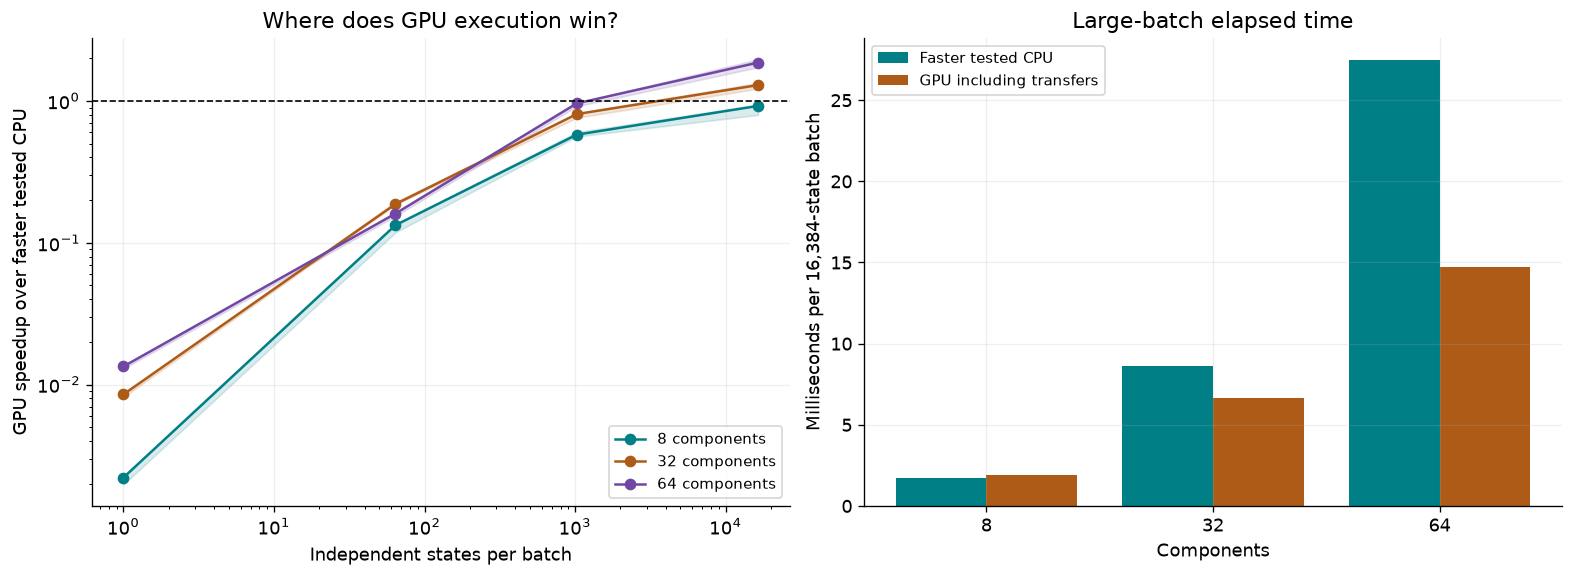

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7), constrained_layout=True)
colors = {8: "#007f86", 32: "#ad5b16", 64: "#7047a3"}
for components, color in colors.items():
    group = summary.loc[components]
    axes[0].plot(group.index, group["speedup"], "o-", color=color, label=f"{components} components")
    axes[0].fill_between(group.index, group["fork_min"], group["fork_max"], color=color, alpha=0.15)
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[0].set(xscale="log", yscale="log", xlabel="Independent states per batch",
            ylabel="GPU speedup over faster tested CPU", title="Where does GPU execution win?")
axes[0].legend(fontsize=9)
large = summary.xs(16384, level="states")
positions = np.arange(len(large))
axes[1].bar(positions - 0.2, large["best_cpu_ms"], 0.4, label="Faster tested CPU", color="#007f86")
axes[1].bar(positions + 0.2, large["gpu_ms"], 0.4, label="GPU including transfers", color="#ad5b16")
axes[1].set_xticks(positions, large.index)
axes[1].set(xlabel="Components", ylabel="Milliseconds per 16,384-state batch",
            title="Large-batch elapsed time")
axes[1].legend(fontsize=9)
fig.savefig(ARTIFACTS / "gpu_crossover.png", dpi=160)
plt.show()


## 5. A real process model: size is not the same as parallel width

We build twelve independent gas-conditioning trains in one native NeqSim `ProcessSystem`.
Each contains a feed, cooler, separator and gas compressor: 48 registered units. Separator
liquid is a boundary product. All process calculations in this section run on CPU.

Each train has the same ordered component list but a different inlet temperature. This makes
it possible to discuss grouping by model and component signature. Equipment within one train
has dependencies: compression must wait for separation, which must wait for cooling. There
are twelve trains, not 48 simultaneously independent flash requests. A large time-series or
optimization ensemble can widen the batch further; one converged flowsheet may remain too small.


In [12]:
import time

component_names = [
    "methane", "ethane", "propane", "i-butane", "n-butane", "n-pentane", "n-hexane", "CO2",
]
composition = [0.70, 0.10, 0.06, 0.03, 0.025, 0.025, 0.03, 0.03]
assert abs(sum(composition) - 1.0) < 1e-12
process = ns.process.processmodel.ProcessSystem()
trains = []
for train_index in range(12):
    fluid = ns.thermo.system.SystemSrkEos(320.0 + train_index, 60.0)
    for name, fraction in zip(component_names, composition):
        fluid.addComponent(name, fraction)
    fluid.setMixingRule("classic")
    fluid.setTotalFlowRate(1.0, "kg/sec")
    feed = ns.process.equipment.stream.Stream(f"feed_{train_index}", fluid)
    cooler = ns.process.equipment.heatexchanger.Cooler(f"cooler_{train_index}", feed)
    cooler.setOutTemperature(295.0 + 0.25 * train_index)
    separator = ns.process.equipment.separator.Separator(
        f"separator_{train_index}", cooler.getOutletStream()
    )
    compressor = ns.process.equipment.compressor.Compressor(
        f"compressor_{train_index}", separator.getGasOutStream()
    )
    compressor.setOutletPressure(90.0)
    compressor.setIsentropicEfficiency(0.75)
    for equipment in (feed, cooler, separator, compressor):
        process.add(equipment)
    trains.append((feed, cooler, separator, compressor))
started = time.perf_counter()
process.run()
cold_process_seconds = time.perf_counter() - started
process_rows = []
for index, (feed, cooler, separator, compressor) in enumerate(trains):
    inlet_mass = feed.getFlowRate("kg/sec")
    outlet_mass = (
        compressor.getOutletStream().getFlowRate("kg/sec")
        + separator.getLiquidOutStream().getFlowRate("kg/sec")
    )
    mass_error = abs(outlet_mass - inlet_mass) / inlet_mass
    assert mass_error < 1e-8
    process_rows.append({
        "train": index + 1,
        "feed_kg_s": inlet_mass,
        "gas_kg_s": compressor.getOutletStream().getFlowRate("kg/sec"),
        "liquid_kg_s": separator.getLiquidOutStream().getFlowRate("kg/sec"),
        "compressor_kW": compressor.getPower("kW"),
        "gas_out_bara": compressor.getOutletStream().getPressure("bara"),
        "relative_mass_error": mass_error,
    })
process_results = pd.DataFrame(process_rows)
display(process_results.round(8))
print(f"Cold CPU execution of 48 registered units: {cold_process_seconds:.3f} s")
print("Compressor and separator objects remain available in the trains list.")


Cold CPU execution of 48 registered units: 0.258 s
Compressor and separator objects remain available in the trains list.


,train,feed_kg_s,gas_kg_s,liquid_kg_s,compressor_kW,gas_out_bara,relative_mass_error
0,1,1.0,0.680908,0.319092,36.436801,90.0,0.0
1,2,1.0,0.682117,0.317883,36.515320,90.0,0.0
2,3,1.0,0.683326,0.316674,36.593816,90.0,0.0
3,4,1.0,0.684536,0.315464,36.672290,90.0,0.0
4,5,1.0,0.685747,0.314253,36.750743,90.0,0.0
5,6,1.0,0.686958,0.313042,36.829174,90.0,0.0
6,7,1.0,0.688170,0.311830,36.907583,90.0,0.0
7,8,1.0,0.689383,0.310617,36.985972,90.0,0.0
8,9,1.0,0.690597,0.309403,37.064341,90.0,0.0
9,10,1.0,0.691811,0.308189,37.142690,90.0,0.0


In [13]:
process_times = []
for repetition in range(7):
    for index, (feed, cooler, separator, compressor) in enumerate(trains):
        feed.setTemperature(320.0 + index + 0.1 * (repetition % 2))
    started = time.perf_counter()
    process.run()
    elapsed = time.perf_counter() - started
    process_times.append(elapsed)
    for feed, cooler, separator, compressor in trains:
        outlet_mass = (
            compressor.getOutletStream().getFlowRate("kg/sec")
            + separator.getLiquidOutStream().getFlowRate("kg/sec")
        )
        assert abs(outlet_mass - feed.getFlowRate("kg/sec")) < 1e-8
process_timing = pd.DataFrame({
    "run": range(1, 8),
    "CPU_process_ms": np.array(process_times) * 1000.0,
    "purpose": ["warmup"] * 2 + ["measured changed state"] * 5,
})
display(process_timing.round(3))
process_cpu_ms = float(np.median(process_times[2:]) * 1000.0)
print(f"Median changed-state CPU process time: {process_cpu_ms:.3f} ms")
print("No GPU process execution was performed; do not divide this timing by kernel speedup.")


Median changed-state CPU process time: 10.471 ms
No GPU process execution was performed; do not divide this timing by kernel speedup.


,run,CPU_process_ms,purpose
0,1,1.967,warmup
1,2,12.301,warmup
2,3,12.578,measured changed state
3,4,11.465,measured changed state
4,5,10.471,measured changed state
5,6,9.263,measured changed state
6,7,8.566,measured changed state


## 6. Estimate the process opportunity without overstating the result

If a fraction $f$ of baseline process time can use an accelerated kernel of speedup $s$,
and additional integration overhead is a fraction $h$ of baseline time, an illustrative bound is:

$$S_{\mathrm{process}}=\frac{1}{(1-f)+f/s+h}$$

The measured $s$ already includes the kernel benchmark's transfers. Thus $h$ is **additional**
packing, queueing, scheduling and result-application overhead, not the same transfers counted
again. This model also assumes enough independent states to achieve the measured batch speed.

The example process above has eight components and only twelve independent trains; it has
not demonstrated the conditions for the 64-component, 16,384-state speedup. The next figure is
an explicitly hypothetical capacity study using the measured large-batch kernel speed.
The eligible time fraction must eventually come from profiling the actual process.


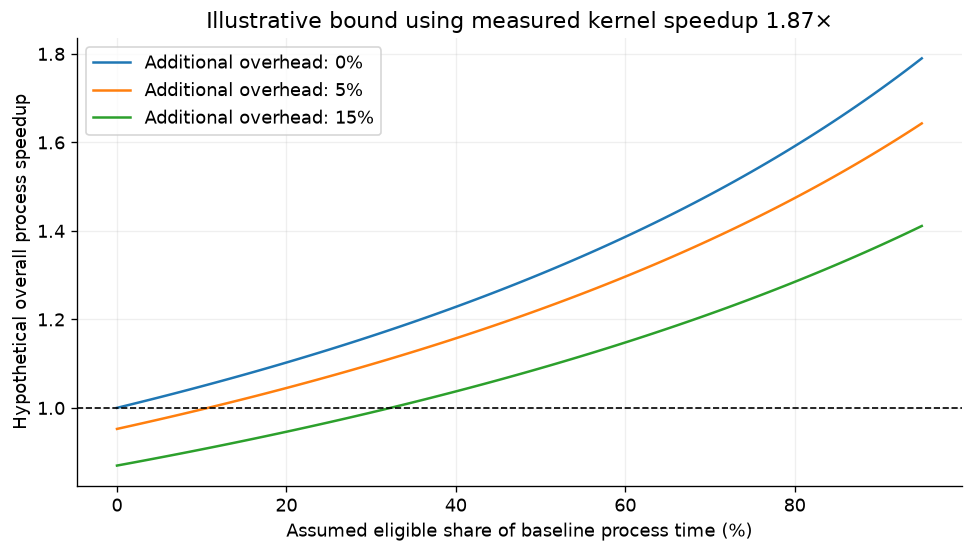

,assumed_eligible_fraction,assumed_extra_overhead,hypothetical_process_speedup
0,0.2,0.00,1.102
1,0.2,0.05,1.045
2,0.5,0.00,1.302
3,0.5,0.05,1.223
4,0.8,0.00,1.591
5,0.8,0.05,1.474


In [14]:
measured_kernel_speedup = float(summary.loc[(64, 16384), "speedup"])
eligible_fractions = np.linspace(0.0, 0.95, 100)
fig, axis = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
for extra_overhead in (0.0, 0.05, 0.15):
    overall_speedup = 1.0 / (
        1.0 - eligible_fractions
        + eligible_fractions / measured_kernel_speedup
        + extra_overhead
    )
    axis.plot(eligible_fractions * 100.0, overall_speedup,
              label=f"Additional overhead: {extra_overhead:.0%}")
axis.axhline(1.0, color="black", linestyle="--", linewidth=1)
axis.set(xlabel="Assumed eligible share of baseline process time (%)",
         ylabel="Hypothetical overall process speedup",
         title=f"Illustrative bound using measured kernel speedup {measured_kernel_speedup:.2f}×")
axis.legend()
fig.savefig(ARTIFACTS / "process_speedup_bound.png", dpi=160)
plt.show()
scenario_rows = []
for eligible_fraction in (0.2, 0.5, 0.8):
    for extra_overhead in (0.0, 0.05):
        estimated = 1.0 / (
            1.0 - eligible_fraction
            + eligible_fraction / measured_kernel_speedup
            + extra_overhead
        )
        scenario_rows.append({
            "assumed_eligible_fraction": eligible_fraction,
            "assumed_extra_overhead": extra_overhead,
            "hypothetical_process_speedup": estimated,
        })
display(pd.DataFrame(scenario_rows).round(3))


## 7. How to implement this for large process calculations

### Start with an explicit batch thermodynamics interface

Keep `ProcessSystem`, `ProcessModel`, streams and equipment as the public model. Introduce an
**optional proposed** numerical service beneath flash/property calculations. The names below
are design suggestions, not existing NeqSim APIs.

| Layer | Proposed responsibility | Required evidence |
|---|---|---|
| Process profiling | Count equipment runs, flashes, init levels, iterations, allocations and time | Identify required thermodynamic work versus duplicate work |
| Batch request | Immutable request ID, state version, EOS, alpha/mixing rule, ordered components, T/P/composition and requested derivatives | SI-unit and model-signature validation |
| Dispatcher | Group compatible independent states; choose serial CPU, CPU workers or GPU using measured crossover | Packing and queue latency included |
| Device session | Cache model constants and compiled plans; maintain per-state scratch arrays | No shared mutable fluid objects; explicit version invalidation |
| Numeric backend | Fused SRK/PR properties, later complete batched stability/flash | Phase/root correctness and FP64 qualification |
| Result acceptance | Restore by request ID; reject stale/nonfinite/unconverged results before mutating streams | Same convergence and conservation gates as CPU |
| Observability | Log selected backend, fallback reason, data bytes and timing breakdown | Every fallback visible and benchmarked |

A batch signature must include EOS, alpha function, mixing rule, ordered component identity,
parameter/binary-interaction version and requested derivatives. Never group merely by the
number of components. Temperature-dependent interactions need a separate qualified path.

### Use available independence, without changing the physics

- **Independent operating scenarios and optimization populations:** strongest initial target.
  Batch identical-model states across scenarios; clone or isolate mutable process state per scenario.
- **Parallel trains and independent ProcessModel areas:** batch only work whose inputs are ready.
  Preserve dependency barriers and accepted boundary-stream versions.
- **Recycle iterations:** use the current tear-state snapshot, evaluate eligible independent work,
  then apply updates at the existing convergence barrier. Do not advance dependent units early.
- **Distillation:** batch compatible stage-property evaluations within one nonlinear iteration;
  retain the column solver and its convergence logic. Stage count alone does not establish a win.
- **Dynamics:** batch cells/units at a common integration stage only when dependencies permit.
  Commit results atomically after acceptance; preserve rollback, time-step rejection and controls.
  GPU throughput is not evidence of meeting a real-time latency deadline.

### Keep intermediate flash data on the GPU

Uploading and downloading a small property call every iteration can erase the gain.
A later resident batch-flash design would transfer feed/model inputs once, retain trial phase
compositions, K values, fugacity arrays and convergence flags on device, and copy accepted
results plus diagnostics back. Active-state masks or compaction can reduce work as easy flashes
converge, but must preserve the physical acceptance criteria and per-state iteration limits.
Branch divergence, near-critical roots and variable phase counts remain central difficulties.

Initially retain difficult/unsupported cases on CPU (CPA, electrolyte, reactive and unqualified
phase/root regimes). A production dispatcher can use an explicit, recorded CPU fallback.
The benchmark deliberately disables fallback so GPU claims cannot be contaminated.

### Implementation order and release gates

1. **Profile complete representative processes.** Measure cold, unchanged and nearby-state cases;
   separate orchestration from flash time. Use roadmap [#2939](https://github.com/equinor/neqsim/issues/2939).
2. **Introduce and validate a CPU batch contract.** Preserve component identity, stream versions,
   clone independence, errors and deterministic result mapping before adding a GPU dependency.
3. **Add optional FP64 SRK/PR property backend.** Qualify each model/root regime, cache constants,
   tune layout and dispatch threshold, then measure full transfer-inclusive performance.
4. **Implement complete resident batched flashes.** Coordinate stability/root/phase acceptance with
   [#2937](https://github.com/equinor/neqsim/issues/2937); preserve mass, equilibrium and phase topology.
5. **Integrate at process dependency barriers.** Benchmark serial, wide, multi-area, recycle and
   CPA-control workloads; require the process roadmap's ≥5% median end-to-end benefit and no
   material control regression before enabling a production optimization.

Use repeated fresh-JVM paired baseline/candidate runs with alternating order, the same solver
work and explicit packing/transfer/kernel/acceptance counters. Validate phase count, stability,
component and energy closure, convergence flags and nearby-state behavior. Include full-flash
and full-process time even when kernel timing is impressive. Do not use wall-clock assertions
in ordinary CI. Keep GPU dependencies optional and CPU behavior available on standard Java.


## 8. Conclusions, limitations and exercises

**Measured here:** FP64 SRK property batches on CPU/GPU, GPU numerical agreement, independent
NeqSim gas-property checks, and a CPU-only 48-unit process example. The displayed live measurements
are authoritative for this run. Earlier A100 measurements gave roughly 1.35×/1.96× over eight CPU
workers for 32/64 components at 16,384 states; these are context, not guaranteed outcomes.

**Not measured or implemented:** complete GPU flash, multi-phase stability, liquid/critical root
qualification, CPA/electrolytes, reactive systems or GPU-accelerated `ProcessSystem` execution.
Three JVMs demonstrate repeatability on this machine, not a performance guarantee. The simple
layout and enabled profiler leave optimization room. One-off requests also pay JIT/startup cost.

**Practical recommendation:** investigate large, compatible batches first; keep small requests
on CPU. Increasing the number of sequential units does not by itself create GPU parallelism.

Exercises: vary the CPU worker count; test intermediate batch sizes; compare A100 with T4 using
FP64; reduce returned outputs; then test a qualified device-resident iterative workload. Every
change needs numerical revalidation and new timing evidence. Never infer FP64 performance from
advertised FP16/Tensor Core throughput.

Sources: [TornadoVM 6.1.0 SDK](https://github.com/beehive-lab/TornadoVM/releases/tag/v6.1.0),
[TornadoVM programming model](https://tornadovm.readthedocs.io/en/latest/programming.html),
[NeqSim source](https://github.com/equinor/neqsim/tree/e946713a2e5393cc5932ac9fcf74d6ab561221df),
[process performance roadmap](https://github.com/equinor/neqsim/issues/2939), and
[flash roadmap](https://github.com/equinor/neqsim/issues/2937).


In [15]:
winning_cases = summary[summary["speedup"] > 1.0][["best_cpu_ms", "gpu_ms", "speedup"]]
print("Cases where GPU beat the faster tested CPU baseline:")
display(winning_cases.round(4))
print(f"GPU cases validated: {len(raw_results)}")
print(f"Maximum reported GPU absolute output difference: {cold_results.max_abs_error.max():.3g}")
print("NeqSim gas-property and CPU derivative/root checks: passed")
print("Native process mass-balance checks: passed")
print("Complete GPU flash/process speedup: NOT TESTED")
export_files = [
    path for path in ARTIFACTS.iterdir()
    if path.is_file() and path.suffix in (".csv", ".json", ".log", ".java", ".png")
]
with zipfile.ZipFile("tornado_demo_results.zip", "w", zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(export_files):
        archive.write(path, path.name)
print("Saved tornado_demo_results.zip with source, measurements, figures and provenance.")
print("Release the Colab GPU runtime after saving your results.")


Cases where GPU beat the faster tested CPU baseline:
GPU cases validated: 36
Maximum reported GPU absolute output difference: 5.55e-17
NeqSim gas-property and CPU derivative/root checks: passed
Native process mass-balance checks: passed
Complete GPU flash/process speedup: NOT TESTED
Saved tornado_demo_results.zip with source, measurements, figures and provenance.
Release the Colab GPU runtime after saving your results.


,,best_cpu_ms,gpu_ms,speedup
components,states,,,
32,16384,8.5967,6.6332,1.2960
64,16384,27.4539,14.7026,1.8673
